In [708]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error, r2_score
import joblib

In [666]:
data = pd.read_csv("cars_dataset.csv")
df = data.copy()

In [667]:
df.head()

,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат
3,2057310,Skoda,Octavia,2007,14500,67,0,"Бензин, 1.6 л.",Ручна / Механіка
4,39587514,BMW,5 Series,2017,36200,129,0,"Дизель, 2.99 л.",Автомат


In [668]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18893 entries, 0 to 18892
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         18893 non-null  int64
 1   Mark       18805 non-null  str  
 2   Model      18039 non-null  str  
 3   Year       18893 non-null  int64
 4   Price_USD  18893 non-null  int64
 5   Mileage    18893 non-null  int64
 6   Engine     18893 non-null  int64
 7   Fuel       18893 non-null  str  
 8   Gearbox    18893 non-null  str  
dtypes: int64(5), str(4)
memory usage: 1.3 MB


In [669]:
df.describe()

,ID,Year,Price_USD,Mileage,Engine
count,1.889300e+04,18893.000000,18893.000000,18893.000000,18893.0
mean,3.027777e+07,2011.019796,17951.785635,156.751019,0.0
std,1.601208e+07,9.083425,22083.457517,253.204387,0.0
min,1.891806e+06,1939.000000,0.000000,0.000000,0.0
25%,3.587842e+07,2006.000000,6700.000000,75.000000,0.0
50%,3.948316e+07,2012.000000,12500.000000,150.000000,0.0
75%,3.962777e+07,2018.000000,21455.000000,221.000000,0.0
max,3.965773e+07,2026.000000,399999.000000,32000.000000,0.0


In [670]:
# Видаляємо стовпчик 'ID', бо він не несе ніякої користі.
df = df.drop('ID',axis=1)

In [671]:
engine = df[df['Engine'] == 0]
len(engine)

18893

In [672]:
# Також видаляємо стовпчик 'Engine', бо він не несе ніякої користі.
df = df.drop('Engine',axis=1)

In [673]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат


_______________________________
# Зробимо оглядовий аналіз по графікам



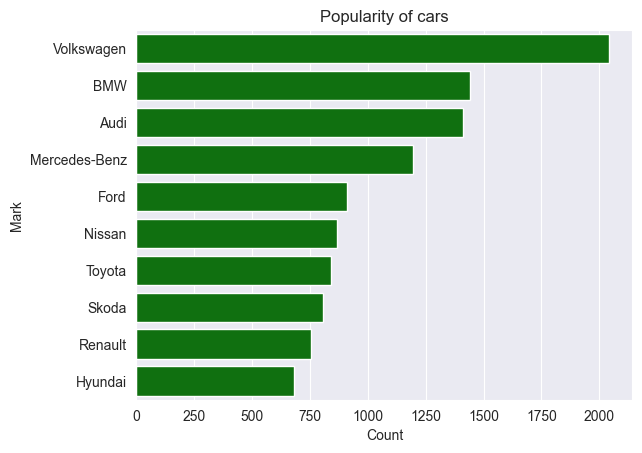

In [674]:
popularity_mark = df['Mark'].value_counts().sort_values(ascending=False)
top_10 = popularity_mark[:10]
sns.barplot(x=top_10.values, y=top_10.index, color='g')
plt.title('Popularity of cars')
plt.xlabel('Count')
plt.ylabel('Mark')
plt.show()

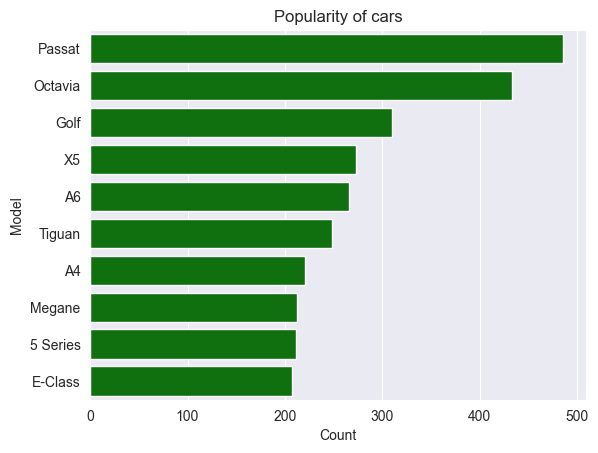

In [675]:
popularity_model = df['Model'].value_counts().sort_values(ascending=False)
top_10 = popularity_model[:10]
sns.barplot(x=top_10.values, y=top_10.index, color='g')
plt.title('Popularity of cars')
plt.xlabel('Count')
plt.ylabel('Model')
plt.show()

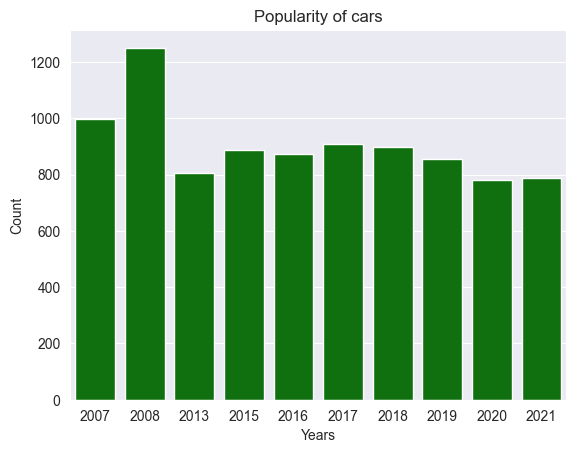

In [676]:
year = df['Year'].value_counts().sort_values(ascending=False)
sns.barplot(year[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Years')
plt.ylabel('Count')
plt.show()

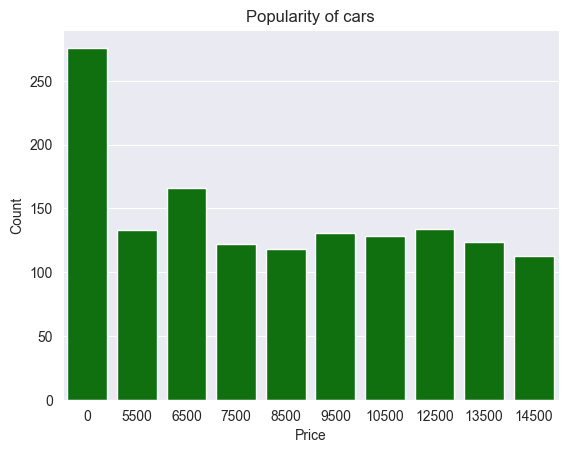

In [677]:
popular_price = df['Price_USD'].value_counts().sort_values(ascending=False)
sns.barplot(popular_price[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Знайшли пусті дані, в нас не можуть коштувати авто 0. Тому нам прийдеться видалити всі авто, які не мають ціну.

In [678]:
df['Price_USD'].isna().sum()

np.int64(0)

In [679]:
df = df[df['Price_USD'] != 0]
df.shape

(18617, 7)

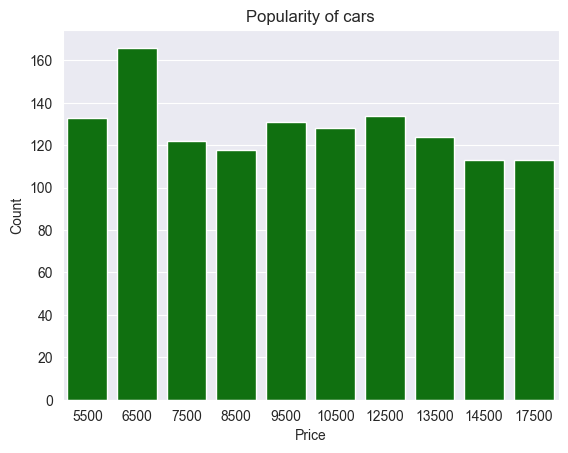

In [680]:
popular_price = df['Price_USD'].value_counts().sort_values(ascending=False)
sns.barplot(popular_price[:10], color='g')
plt.title('Popularity of cars')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

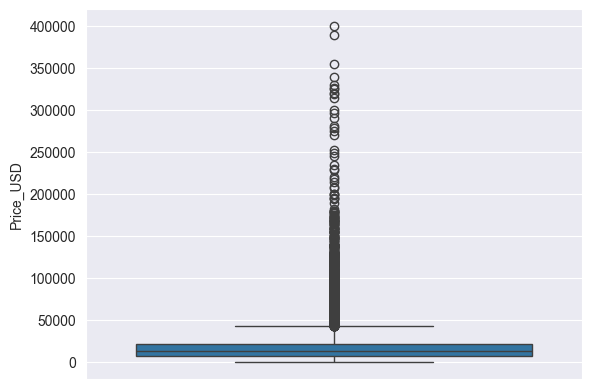

In [681]:
sns.boxplot(df['Price_USD'])
plt.show()

In [682]:
# Перевіряємо, чи дійсно авто, які коштують більше n записані в $, а не в гривнях
car_more_than = df[df['Price_USD'] > 300000]
car_more_than

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
3160,Mercedes-Benz,G-Class,2024,314999,11,"Гібрид (HEV), 3.98 л.",Автомат
9207,Aston Martin,DBX 707,2025,399999,1,"Бензин, 3.98 л.",Автомат
9740,Mercedes-Benz,G-Class,2025,319000,9,"Гібрид (HEV), 3.98 л.",Автомат
11266,Aston Martin,DBX 707,2024,355555,1,"Бензин, 4 л.",Автомат
11414,Rolls-Royce,Cullinan,2019,329999,63,"Бензин, 6.75 л.",Автомат
11727,Mercedes-Benz,G-Class,2025,325500,10,"Бензин, 3.98 л.",Автомат
12258,Mercedes-Benz,G-Class,2023,340000,17,"Бензин, 3.98 л.",Автомат
14414,Rolls-Royce,Ghost,2020,390000,20,"Бензин, 6.75 л.",Автомат
17641,Lamborghini,Huracan EVO,2020,320900,9,"Бензин, 5.2 л.",Автомат
18432,Mercedes-Benz,G-Class,2025,325900,1,"Бензин, 4 л.",Автомат


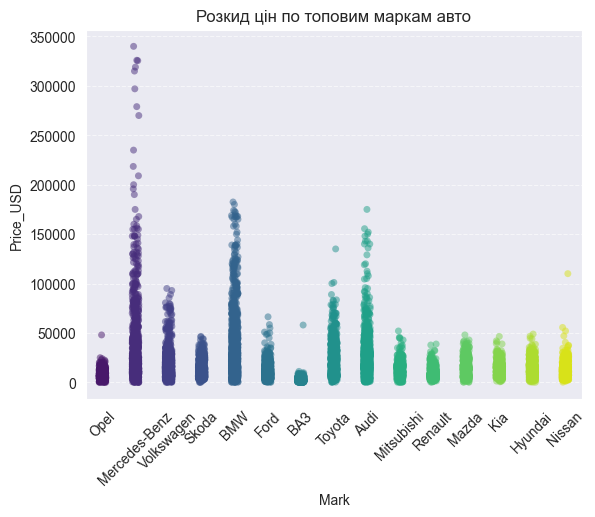

In [683]:
top_marks = df['Mark'].value_counts().nlargest(15).index
df_filtered = df[df['Mark'].isin(top_marks)]

sns.stripplot(
    data=df_filtered,
    x='Mark',
    y='Price_USD',
    hue='Mark',
    jitter=True,
    alpha=0.5,
    palette='viridis',
    legend=False
)


plt.title('Розкид цін по топовим маркам авто')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

_______________________
# Створення нових фіч


In [684]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат


In [685]:
# Порахували скільки років кожній моделі

df['Age'] = 2026 - df['Year']
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox,Age
0,Opel,Omega,1990,1900,300,"Бензин, 1.8 л.",Ручна / Механіка,36
1,Mercedes-Benz,eVito,2021,27800,257,Електро,Автомат,5
2,Volkswagen,E-Tharu,2020,18000,31,Електро,Автомат,6


In [686]:
# Розділили 'Fuel' на об'єм двигуна та тип двигуна

split_data = df['Fuel'].str.split(', ', expand=True)
df['Fuel_Type'] = split_data[0]

cleaned_capacity = split_data[1].str.replace(' л.', '')
df['Engine_Capacity'] = pd.to_numeric(cleaned_capacity, errors='coerce').fillna(0)

df.drop('Fuel', axis=1, inplace=True)

In [687]:
df.head()

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.80
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.00
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.00
3,Skoda,Octavia,2007,14500,67,Ручна / Механіка,19,Бензин,1.60
4,BMW,5 Series,2017,36200,129,Автомат,9,Дизель,2.99


In [688]:
# Інтенсивність експлуатації (Пробіг за рік)
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)

In [689]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.8,8.108108
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.0,42.833333
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.0,4.428571


In [690]:
# 1. Додаємо нові корисні фічі до існуючого df
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)

__________________
# Робимо очищення, стандартизацію Дата-сету

In [691]:
df.isna().sum()

Mark                      75
Model                    789
Year                       0
Price_USD                  0
Mileage                    0
Gearbox                    0
Age                        0
Fuel_Type                  0
Engine_Capacity            0
Km_per_Year                0
is_EV                      0
is_suspicious_mileage      0
dtype: int64

In [692]:
df.info()

<class 'pandas.DataFrame'>
Index: 18617 entries, 0 to 18892
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Mark                   18542 non-null  str    
 1   Model                  17828 non-null  str    
 2   Year                   18617 non-null  int64  
 3   Price_USD              18617 non-null  int64  
 4   Mileage                18617 non-null  int64  
 5   Gearbox                18617 non-null  str    
 6   Age                    18617 non-null  int64  
 7   Fuel_Type              18617 non-null  str    
 8   Engine_Capacity        18617 non-null  float64
 9   Km_per_Year            18617 non-null  float64
 10  is_EV                  18617 non-null  int64  
 11  is_suspicious_mileage  18617 non-null  int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 1.8 MB


In [693]:
df['Mark'] = df['Mark'].fillna('Unknown')
df['Model'] = df['Model'].fillna('Unknown')

In [694]:
# Позбулися даних, в яких є пропуски.
# Ми не могли замінити модою, бо це б дуже сильно повпливало на ціну авто та predict в моделі.

print("Початковий розмір дата-сету:",data.shape)
print("Оновлений розмір дата-сету",df.shape)

Початковий розмір дата-сету: (18893, 9)
Оновлений розмір дата-сету (18617, 12)


In [695]:
df.head(7)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year,is_EV,is_suspicious_mileage
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.80,8.108108,0,0
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.00,42.833333,1,0
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.00,4.428571,1,0
3,Skoda,Octavia,2007,14500,67,Ручна / Механіка,19,Бензин,1.60,3.350000,0,0
4,BMW,5 Series,2017,36200,129,Автомат,9,Дизель,2.99,12.900000,0,0
5,BMW,5 Series,2020,44200,77,Автомат,6,Бензин,3.00,11.000000,0,0
6,BMW,5 Series,2015,19200,205,Автомат,11,Дизель,2.00,17.083333,0,0


___________________________
# Навчання моделі

In [696]:
df.columns

Index(['Mark', 'Model', 'Year', 'Price_USD', 'Mileage', 'Gearbox', 'Age',
       'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV',
       'is_suspicious_mileage'],
      dtype='str')

In [697]:
df.head(3)

,Mark,Model,Year,Price_USD,Mileage,Gearbox,Age,Fuel_Type,Engine_Capacity,Km_per_Year,is_EV,is_suspicious_mileage
0,Opel,Omega,1990,1900,300,Ручна / Механіка,36,Бензин,1.8,8.108108,0,0
1,Mercedes-Benz,eVito,2021,27800,257,Автомат,5,Електро,0.0,42.833333,1,0
2,Volkswagen,E-Tharu,2020,18000,31,Автомат,6,Електро,0.0,4.428571,1,0


In [698]:
df_final = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 150000) &
    (df['Year'] >= 2000)
].copy()

In [699]:
features = ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage']
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

In [700]:
X = df_final[features]
y = df_final['Price_USD']
y_log = np.log1p(y)

In [701]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [702]:
mark_counts = X_train['Mark'].value_counts()
model_counts = X_train['Model'].value_counts()

# Створюємо списки частих марок/моделей (наприклад, зустрічаються 5 і більше разів)
valid_marks = mark_counts[mark_counts >= 5].index
valid_models = model_counts[model_counts >= 5].index

# Застосовуємо логіку "Other" до обох вибірок
X_train['Mark'] = X_train['Mark'].apply(lambda x: x if x in valid_marks else 'Other')
X_test['Mark'] = X_test['Mark'].apply(lambda x: x if x in valid_marks else 'Other')

X_train['Model'] = X_train['Model'].apply(lambda x: x if x in valid_models else 'Other')
X_test['Model'] = X_test['Model'].apply(lambda x: x if x in valid_models else 'Other')

In [703]:
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    eval_metric='MAPE',
    verbose=500
)

In [704]:
print("Починаємо навчання моделі...")
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150 # Зупиняємось, якщо 150 кроків немає покращення
)

Починаємо навчання моделі...
0:	learn: 0.0644000	test: 0.0642603	best: 0.0642603 (0)	total: 72.6ms	remaining: 3m 37s
500:	learn: 0.0175163	test: 0.0205997	best: 0.0205997 (500)	total: 36.7s	remaining: 3m 2s
1000:	learn: 0.0150776	test: 0.0198779	best: 0.0198767 (992)	total: 1m 17s	remaining: 2m 35s
1500:	learn: 0.0134414	test: 0.0195975	best: 0.0195975 (1500)	total: 1m 59s	remaining: 1m 59s
2000:	learn: 0.0121545	test: 0.0194532	best: 0.0194481 (1982)	total: 2m 33s	remaining: 1m 16s
2500:	learn: 0.0111419	test: 0.0194359	best: 0.0194262 (2363)	total: 3m 5s	remaining: 36.9s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.01942623766
bestIteration = 2363

Shrink model to first 2364 iterations.


CatBoostRegressor(depth=8, eval_metric='MAPE', iterations=3000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=500)

In [705]:
# Оцінка результатів
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log) # Повертаємо ціни у звичайні долари
y_test_real = np.expm1(y_test)

print(f"\n--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---")
print(f"MAE (Середня похибка в доларах): {mean_absolute_error(y_test_real, y_pred):.2f} USD")
print(f"MAPE (Середня похибка у відсотках): {mean_absolute_percentage_error(y_test_real, y_pred)*100:.2f}%")
print("R2_score", r2_score(y_test_real, y_pred))


--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---
MAE (Середня похибка в доларах): 3029.61 USD
MAPE (Середня похибка у відсотках): 21.15%
R2_score 0.8760345835450506


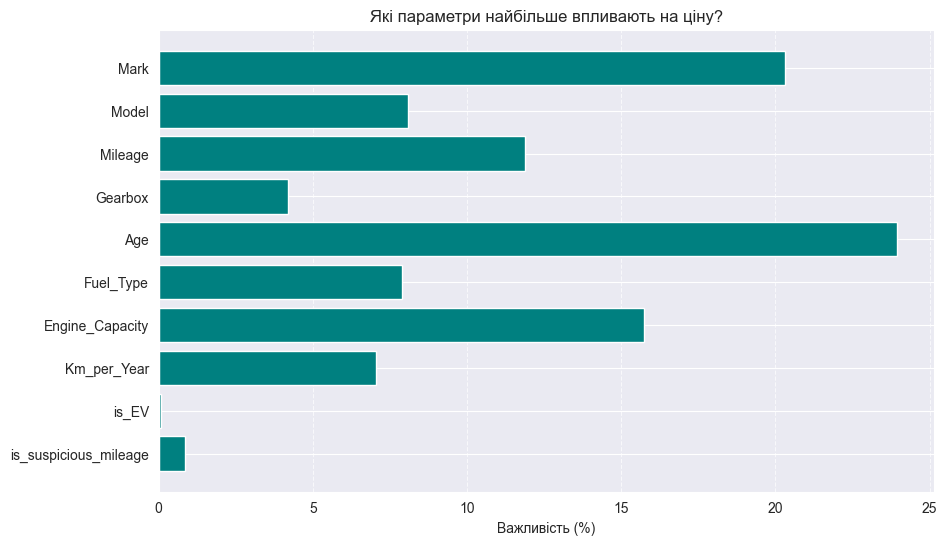

In [706]:
# Виведення важливості ознак
importance = model.get_feature_importance()
plt.figure(figsize=(10, 6))
plt.barh(features, importance, color='teal')
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну?')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

_______________________________
# Збереження моделі

In [711]:
model.save_model('catboost_car_price_model.cbm')

valid_categories = {
    'valid_marks': list(valid_marks),
    'valid_models': list(valid_models)
}
joblib.dump(valid_categories, 'valid_categories.pkl')

['valid_categories.pkl']